In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [6]:
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
strategy = pd.read_parquet("data_processed/f1_feature_store_strategy.parquet")

In [7]:
print("Master:", master.shape)
print("Pre-race:", prerace.shape)
print("Strategy:", strategy.shape)

Master: (26759, 103)
Pre-race: (26759, 49)
Strategy: (26759, 67)


In [8]:
master.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,laps,time_x,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name_x,date,time_y,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,driverRef,number_y,code,forename,surname,dob,nationality_x,constructorRef,name_y,nationality_y,circuitRef,name,location,country,lat,lng,alt,status,temp_avg,temp_max,temp_min,precipitation,wind_speed,humidity_avg,month,abs_lat,temp_range,is_wet_race,high_altitude_track,qualifying_position,best_qualifying_time_ms,made_q2,made_q3,sprint_grid,sprint_position_order,sprint_points,sprint_laps,sprint_milliseconds,sprint_status_id,pit_stop_count,avg_pit_stop_ms,min_pit_stop_ms,max_pit_stop_ms,total_pit_stop_ms,first_pit_lap,last_pit_lap,lap_count_recorded,avg_lap_time_ms,median_lap_time_ms,std_lap_time_ms,fastest_lap_in_race_ms,slowest_lap_ms,target_points,finish_position,grid_clean,is_dnf,driver_avg_finish_last5,driver_points_last5,driver_dnf_rate_last5,driver_avg_grid_last5,constructor_points_last5,constructor_dnf_rate_last5,constructor_avg_finish_last5,driver_standing_points_prerace,driver_standing_position_prerace,driver_standing_wins_prerace,constructor_standing_points_prerace,constructor_standing_position_prerace,constructor_standing_wins_prerace
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616.0,39,2,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,mclaren,McLaren,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98114.068966,88665.5,20990.356845,87452.0,166432.0,1,1,1.0,0,6.6,25.0,0.2,2.0,16.0,0.4,10.4,109.0,2.0,4.0,218.0,11.0,8.0
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094.0,41,3,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,bmw_sauber,BMW Sauber,German,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,5.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98208.517241,89388.0,20212.298423,87739.0,166678.0,1,2,5.0,0,7.2,14.0,0.2,5.8,9.0,0.4,10.0,61.0,5.0,0.0,101.0,2.0,0.0
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779.0,41,5,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,williams,Williams,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,7.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98254.810345,89585.0,18957.199698,88090.0,156683.0,1,3,7.0,0,10.0,11.0,0.2,10.8,5.0,0.2,12.8,20.0,9.0,0.0,33.0,4.0,0.0
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797.0,58,7,1:28.603,215.464,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,renault,Renault,French,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,12.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.0,98410.293103,90668.5,19640.823974,88603.0,170306.0,1,4,11.0,0,6.0,30.0,0.2,2.8,4.0,0.4,12.8,109.0,3.0,4.0,51.0,3.0,0.0
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630.0,43,1,1:27.418,218.385,1,2008,1,1,Australian Grand Prix,2008-03-16,04:30:00,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,mclaren,McLaren,British,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,Finished,27.9,38.4,18.1,0.0,23.1,41.0,3,37.8497,20.3,0,0,3.0,NaN,0.0,0.0,Na

## Initial EDA and Data Audit
Before examining distribution shape and dimensionality, inspect the feature store structure, missingness, and variable coverage across the master, pre-race, and strategy tables.

In [9]:
feature_store_summary = pd.DataFrame({
    "table": ["master", "prerace", "strategy"],
    "rows": [master.shape[0], prerace.shape[0], strategy.shape[0]],
    "columns": [master.shape[1], prerace.shape[1], strategy.shape[1]]
})

feature_store_summary

,table,rows,columns
0,master,26759,103
1,prerace,26759,49
2,strategy,26759,67


In [10]:
# Shapes and Columns

master.columns.tolist()[:50]

prerace.columns.tolist()[:50]

strategy.columns.tolist()[:80]

['raceId',
 'driverId',
 'constructorId',
 'circuitId',
 'date',
 'year',
 'round',
 'target_points',
 'finish_position',
 'positionOrder',
 'points',
 'grid',
 'grid_clean',
 'qualifying_position',
 'best_qualifying_time_ms',
 'made_q2',
 'made_q3',
 'driver_avg_finish_last5',
 'driver_points_last5',
 'driver_dnf_rate_last5',
 'driver_avg_grid_last5',
 'constructor_points_last5',
 'constructor_dnf_rate_last5',
 'constructor_avg_finish_last5',
 'driver_standing_points_prerace',
 'driver_standing_position_prerace',
 'driver_standing_wins_prerace',
 'constructor_standing_points_prerace',
 'constructor_standing_position_prerace',
 'constructor_standing_wins_prerace',
 'lat',
 'lng',
 'alt',
 'abs_lat',
 'temp_avg',
 'temp_max',
 'temp_min',
 'temp_range',
 'precipitation',
 'wind_speed',
 'humidity_avg',
 'month',
 'is_wet_race',
 'high_altitude_track',
 'sprint_grid',
 'sprint_position_order',
 'sprint_points',
 'sprint_laps',
 'sprint_milliseconds',
 'pit_stop_count',
 'avg_pit_stop_ms'

In [11]:
# Missingness Summary
def missing_summary(df, name, top_n=20):
    out = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame("missing_pct")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    out["table"] = name
    return out



In [12]:
missing_master = missing_summary(master, "master")
missing_prerace = missing_summary(prerace, "prerace")
missing_strategy = missing_summary(strategy, "strategy")

In [13]:
pd.concat([missing_master, missing_prerace, missing_strategy], ignore_index=True)

,column,missing_pct,table
0,best_qualifying_time_ms,1.000000,master
1,sprint_milliseconds,0.987294,master
2,sprint_points,0.986547,master
3,sprint_laps,0.986547,master
4,sprint_position_order,0.986547,master
5,sprint_status_id,0.986547,master
6,sprint_grid,0.986547,master
7,pit_stop_count,0.791659,master
8,total_pit_stop_ms,0.791659,master
9,first_pit_lap,0.791659,master


In [14]:
# Numeric Variable Coverage
def numeric_profile(df, name):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    return pd.DataFrame({
        "table": [name],
        "numeric_columns": [len(num_cols)],
        "total_columns": [df.shape[1]]
    })

pd.concat([
    numeric_profile(master, "master"),
    numeric_profile(prerace, "prerace"),
    numeric_profile(strategy, "strategy")
], ignore_index=True)


,table,numeric_columns,total_columns
0,master,67,103
1,prerace,48,49
2,strategy,63,67


## Defining Working Dataframes
Use different slices of the feature store depending on the statistical question:
- `df_outcomes` for finish position and points distributions
- `df_strategy` for pit stop and lap-time distributions
- `df_prerace` for correlation structure, multicollinearity, and PCA


In [15]:
df_outcomes = master.copy()
df_strategy = strategy.copy()
df_prerace = prerace.copy()
df = strategy.copy()

## Outcome Distribution EDA

In [16]:
OUTCOME_VARS = [
    "finish_position",
    "points",
    "grid_clean",
    "qualifying_position"
]

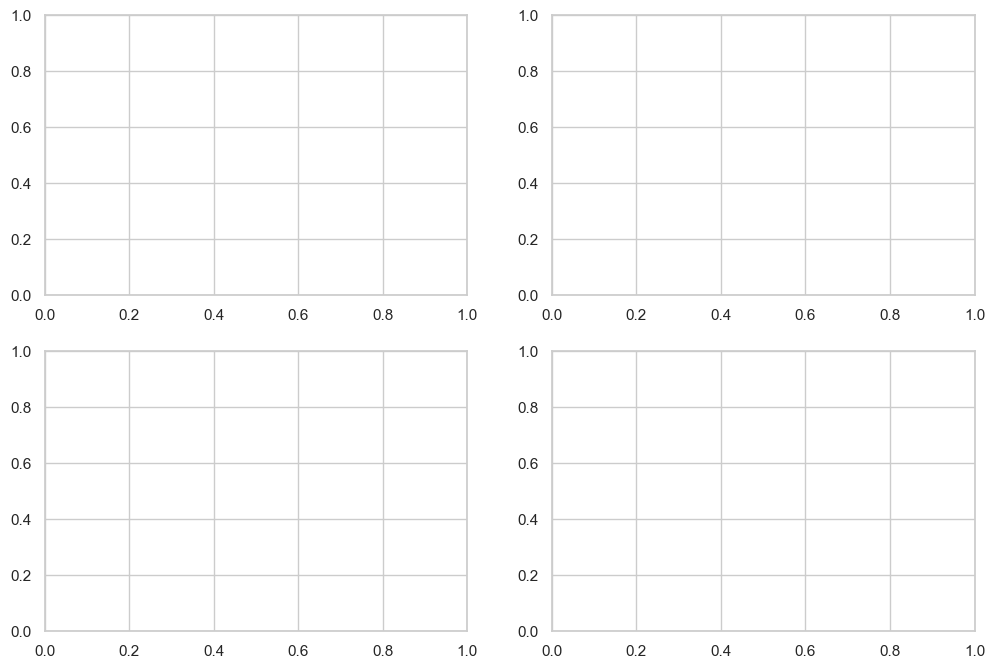

In [17]:
df_outcomes[OUTCOME_VARS].describe()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

In [18]:
for ax, col in zip(axes.flatten(), OUTCOME_VARS):
    sns.histplot(df_outcomes[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [19]:
# Shape Summary
shape_summary_outcomes = []

for col in OUTCOME_VARS:
    series = df_outcomes[col].dropna()
    shape_summary_outcomes.append({
        "variable": col,
        "mean": series.mean(),
        "std": series.std(),
        "skewness": skew(series),
        "kurtosis": kurtosis(series)
    })

shape_summary_outcomes = pd.DataFrame(shape_summary_outcomes)
shape_summary_outcomes

,variable,mean,std,skewness,kurtosis
0,finish_position,12.794051,7.665951,0.399360,-0.474495
1,points,1.987632,4.351209,3.043936,10.730907
2,grid_clean,11.860834,6.830260,0.205085,-0.880242
3,qualifying_position,11.195826,6.260374,0.080556,-1.074988


## Strategy Variable Distribution EDA

In [20]:
STRATEGY_VARS = [
    "pit_stop_count",
    "avg_pit_stop_ms",
    "total_pit_stop_ms",
    "first_pit_lap",
    "last_pit_lap",
    "avg_lap_time_ms",
    "std_lap_time_ms"
]

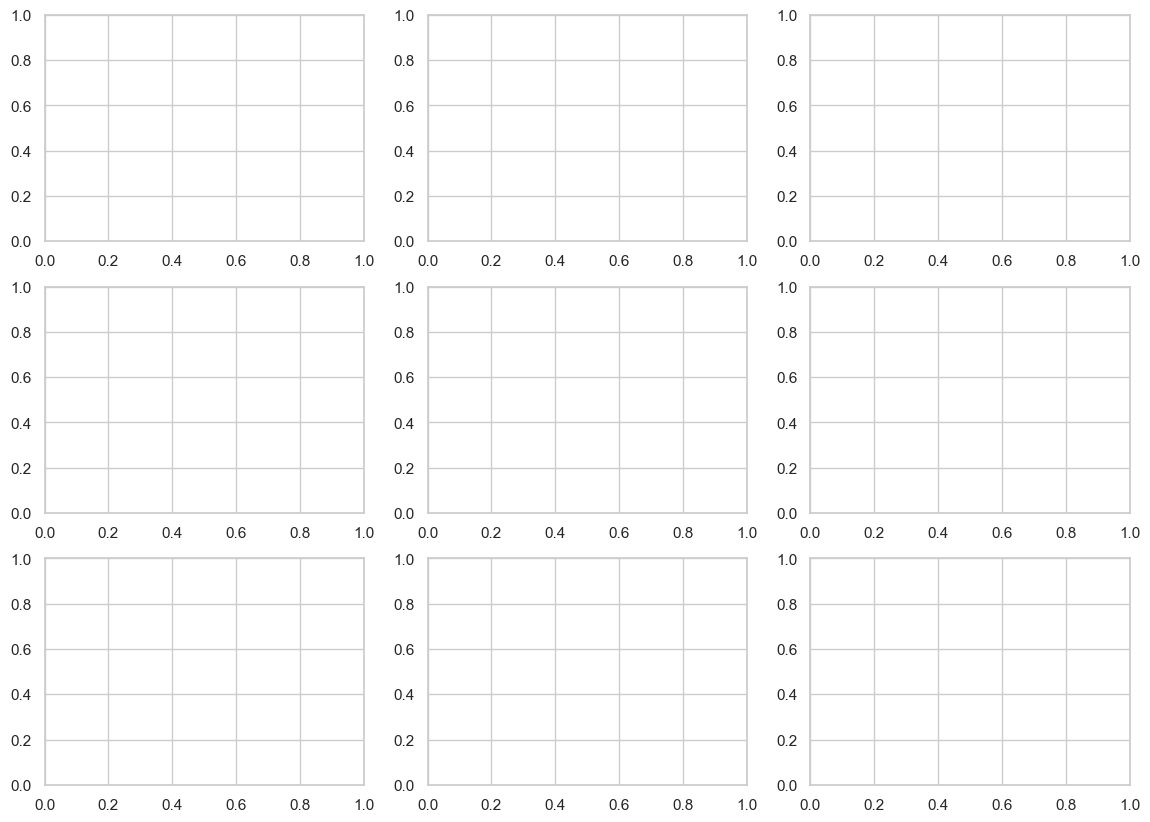

In [21]:
df_strategy[STRATEGY_VARS].describe()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

<Figure size 640x480 with 0 Axes>

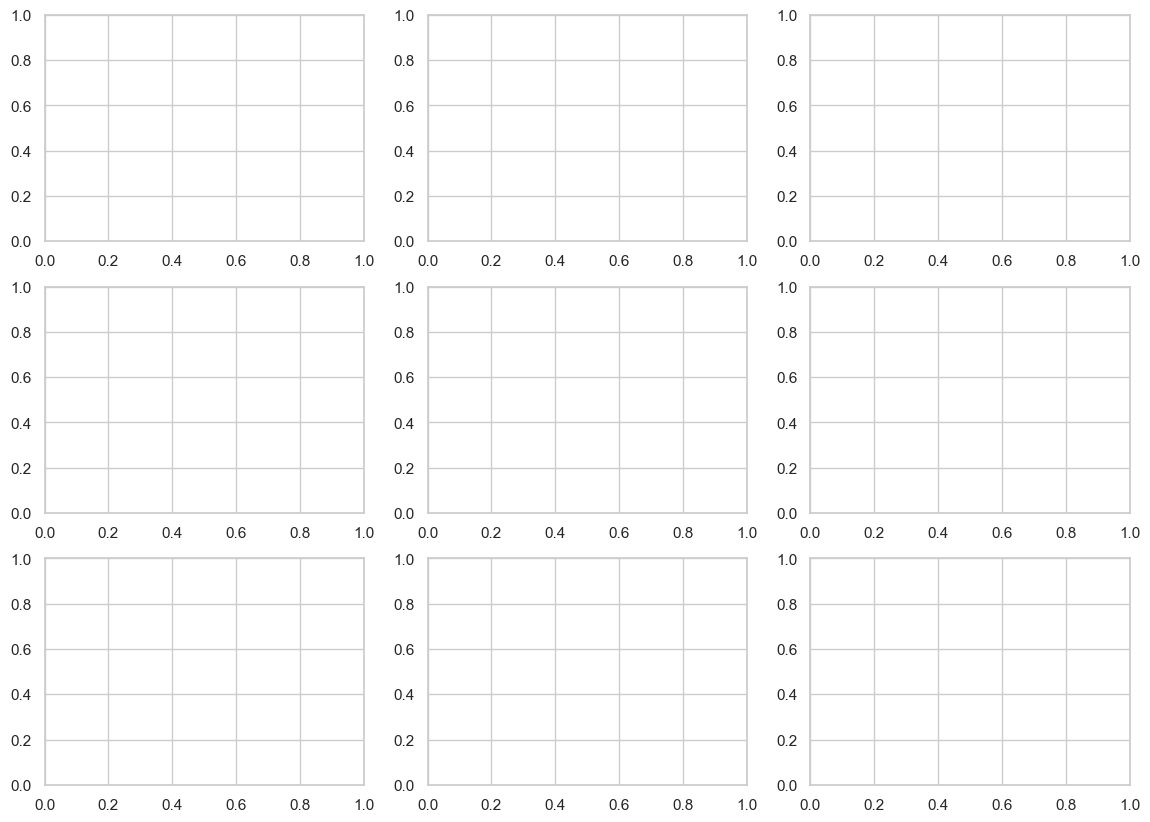

In [23]:
for i, col in enumerate(STRATEGY_VARS):
    sns.histplot(df_strategy[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

In [25]:
for i, col in enumerate(STRATEGY_VARS):
    sns.histplot(df_strategy[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [24]:
# Shape Summary
shape_summary_strategy = []

for col in STRATEGY_VARS:
    series = df_strategy[col].dropna()
    shape_summary_strategy.append({
        "variable": col,
        "mean": series.mean(),
        "std": series.std(),
        "skewness": skew(series),
        "kurtosis": kurtosis(series)
    })

shape_summary_strategy = pd.DataFrame(shape_summary_strategy)
shape_summary_strategy

,variable,mean,std,skewness,kurtosis
0,pit_stop_count,2.039641,0.989017,1.023438,1.277907
1,avg_pit_stop_ms,71885.239934,205491.140261,6.187065,49.948050
2,total_pit_stop_ms,173839.634978,496963.064246,4.425547,20.749362
3,first_pit_lap,16.395157,10.282993,0.679463,0.318324
4,last_pit_lap,33.643049,12.936513,-0.049231,-0.068618
5,avg_lap_time_ms,98540.311539,22402.558441,6.853179,126.543370
6,std_lap_time_ms,22662.749717,73150.958097,7.816241,82.242238


## Transformations

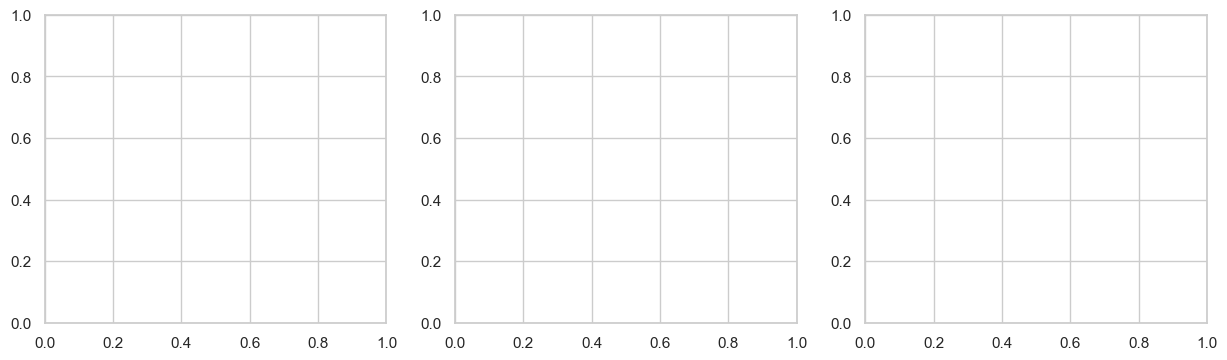

In [27]:
df_strategy["log_avg_pit_stop_ms"] = np.log1p(df_strategy["avg_pit_stop_ms"])
df_strategy["log_total_pit_stop_ms"] = np.log1p(df_strategy["total_pit_stop_ms"])

pt = PowerTransformer(method="yeo-johnson")

df_strategy["avg_pit_stop_ms_yeojohnson"] = pt.fit_transform(
    df_strategy[["avg_pit_stop_ms"]]
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

In [28]:
sns.histplot(df_strategy["avg_pit_stop_ms"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Original avg_pit_stop_ms")

Text(0.5, 1.0, 'Original avg_pit_stop_ms')

In [29]:
sns.histplot(df_strategy["log_avg_pit_stop_ms"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Log-transformed")

Text(0.5, 1.0, 'Log-transformed')

In [30]:
sns.histplot(df_strategy["avg_pit_stop_ms_yeojohnson"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("Yeo-Johnson transformed")

Text(0.5, 1.0, 'Yeo-Johnson transformed')

In [31]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

## Correlation Structure and Multicollinearity

In [32]:
PRERACE_MODEL_VARS = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed"
]
corr_df = df_prerace[PRERACE_MODEL_VARS].apply(pd.to_numeric, errors="coerce").dropna()
corr = corr_df.corr()

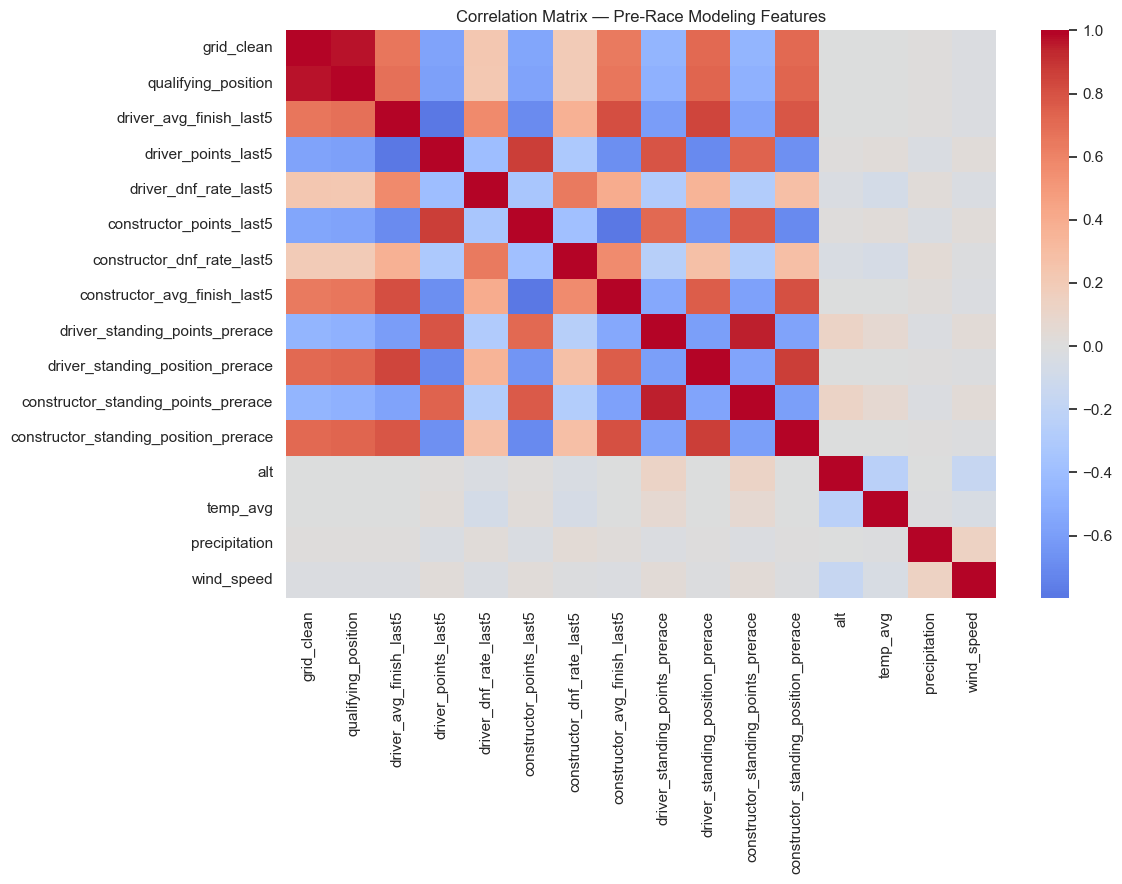

In [33]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Pre-Race Modeling Features")
plt.tight_layout()
plt.show()

In [34]:
# VIF
vif_df = pd.DataFrame()
vif_df["feature"] = corr_df.columns
vif_df["VIF"] = [
    variance_inflation_factor(corr_df.values, i)
    for i in range(corr_df.shape[1])
]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
2,driver_avg_finish_last5,104.692550
7,constructor_avg_finish_last5,94.298362
1,qualifying_position,78.313028
0,grid_clean,71.704923
11,constructor_standing_position_prerace,27.257133
8,driver_standing_points_prerace,26.128272
10,constructor_standing_points_prerace,25.333106
9,driver_standing_position_prerace,24.897652
3,driver_points_last5,20.111512
5,constructor_points_last5,19.217031


## PCA (Principal Components Analysis)

In [37]:
X = corr_df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_df = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})
explained_df

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.470148,0.470148
1,2,0.090332,0.560480
2,3,0.080953,0.641433
3,4,0.073425,0.714858
4,5,0.070745,0.785604
5,6,0.056449,0.842052
6,7,0.042892,0.884945
7,8,0.033037,0.917982
8,9,0.030465,0.948447
9,10,0.020143,0.968590


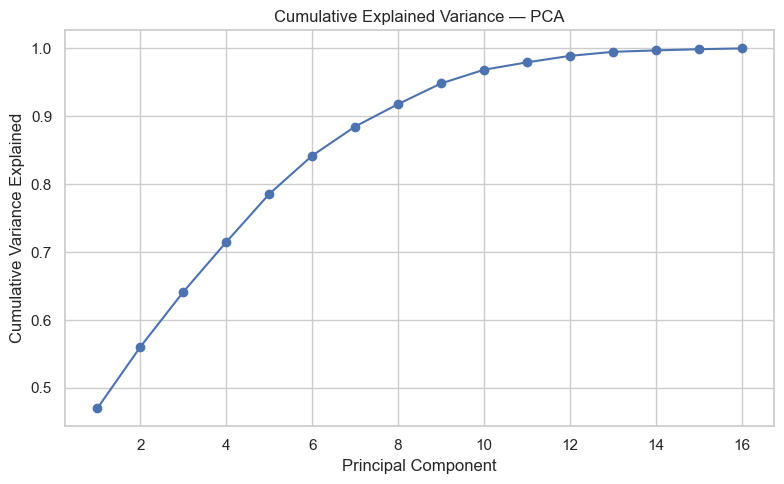

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_df["component"],
    explained_df["cumulative_explained_variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance — PCA")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.tight_layout()
plt.show()

In [40]:
# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, X.shape[1] + 1)]
)

loadings.iloc[:, :4]

,PC1,PC2,PC3,PC4
grid_clean,0.283453,-0.297394,0.153410,0.261122
qualifying_position,0.289957,-0.303260,0.148792,0.246871
driver_avg_finish_last5,0.327148,0.054306,0.064780,0.137652
driver_points_last5,-0.319515,-0.017241,0.083942,0.215296
driver_dnf_rate_last5,0.177032,0.585379,0.042066,0.193959
constructor_points_last5,-0.316596,-0.034286,0.078458,0.198697
constructor_dnf_rate_last5,0.164859,0.612743,0.023618,0.208216
constructor_avg_finish_last5,0.320623,0.081263,0.062147,0.151267
driver_standing_points_prerace,-0.285625,0.006384,0.237311,0.442834
driver_standing_position_prerace,0.318188,-0.133635,0.085406,0.134920


## Circuit Feature Reduction with PCA

In [41]:
circuit_df = (
    master[["circuitId", "lat", "lng", "alt", "abs_lat", "temp_avg", "precipitation", "wind_speed"]]
    .drop_duplicates()
    .dropna()
    .copy()
)
circuit_features = ["lat", "lng", "alt", "abs_lat", "temp_avg", "precipitation", "wind_speed"]

X_circuit = circuit_df[circuit_features]
X_circuit_scaled = StandardScaler().fit_transform(X_circuit)

pca_circuit = PCA()
X_circuit_pca = pca_circuit.fit_transform(X_circuit_scaled)
circuit_explained = pd.DataFrame({
    "component": np.arange(1, len(pca_circuit.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_circuit.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_circuit.explained_variance_ratio_)
})

circuit_explained

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.302443,0.302443
1,2,0.204085,0.506528
2,3,0.160601,0.667128
3,4,0.132342,0.799470
4,5,0.104320,0.903791
5,6,0.056087,0.959878
6,7,0.040122,1.000000


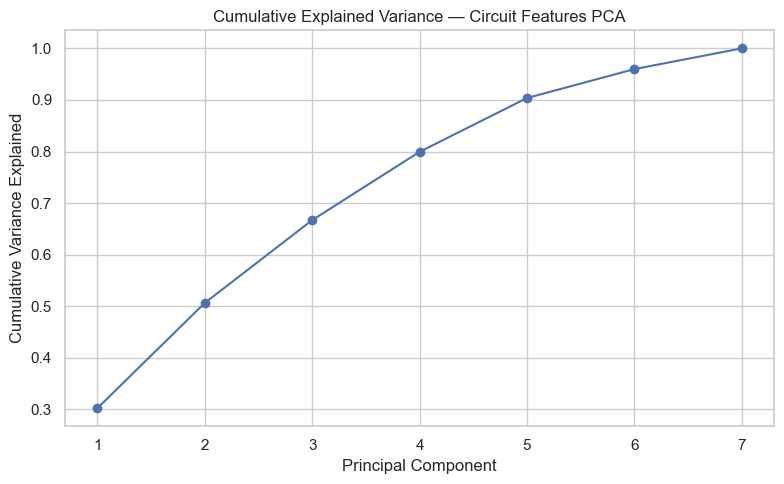

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(
    circuit_explained["component"],
    circuit_explained["cumulative_explained_variance"],
    marker="o"
)
plt.title("Cumulative Explained Variance — Circuit Features PCA")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.tight_layout()
plt.show()

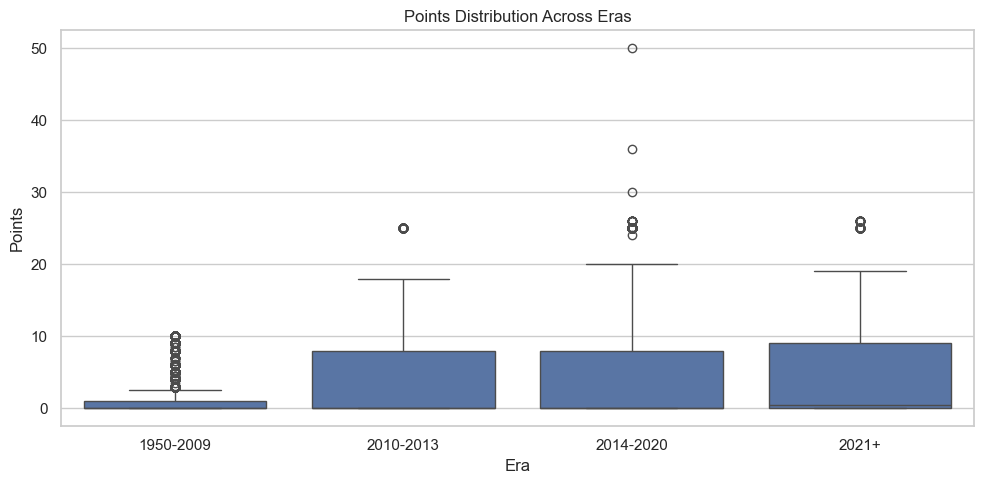

In [43]:
# Era Comparisons
df_outcomes["era"] = pd.cut(
    df_outcomes["year"],
    bins=[1949, 2009, 2013, 2020, 2030],
    labels=["1950-2009", "2010-2013", "2014-2020", "2021+"]
)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_outcomes, x="era", y="points")
plt.title("Points Distribution Across Eras")
plt.xlabel("Era")
plt.ylabel("Points")
plt.tight_layout()
plt.show()



## Core Objective ##

In previous analyses, we focused on predicting outcomes and evaluating strategy.
In this notebook, we step back and examine the statistical structure of the data itself.

The goal is to understand:

- How key variables are distributed
- Where skewness, heavy tails, and non-normality exist
- How transformations impact modeling assumptions
- Whether dimensionality reduction can reveal latent structure

This provides a foundation for more robust modeling decisions and deeper interpretation of Formula 1 dynamics.

In [1]:
DIST_VARS = [
    "finish_position",
    "points",
    "avg_lap_time_ms",
    "std_lap_time_ms",
    "avg_pit_stop_ms",
    "total_pit_stop_ms"
]

In [2]:
GROUP_VARS = ["year", "constructorId", "circuitId"]

## Histograms & KDE ##
- shape
- tails
- multimodality

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in DIST_VARS:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

NameError: name 'df' is not defined

<Figure size 640x480 with 0 Axes>

## Skewness & Kurtosis ##